# Simple Linear Regression: Marketing ROI Analysis

## 1. Project Overview & Objective
The goal of this analysis is to evaluate a marketing dataset to identify which advertising channel (TV, Radio, or Social Media) yields the highest return on investment (ROI). Using **Simple Linear Regression (OLS)**, we will build a statistically valid model to predict Sales and provide a data-driven recommendation for marketing budget allocation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

%matplotlib inline

## 2. Data Cleaning & Preprocessing
### Analytical Reasoning:
The dataset contains 4,572 records. A preliminary check reveals a very low count of missing values across features (TV: 10, Radio: 4, Social Media: 6, Sales: 6). Because the missing rows constitute less than 0.5% of the total dataset, removing them via listwise deletion will not bias our model or significantly reduce statistical power. We will drop these rows to ensure a clean dataset for regression.

In [2]:
# Load the dataset
df = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')

# Check missing values
print(df.isnull().sum())

# Remove rows where Sales is missing
df = df.dropna(subset=['Sales'])

# Remove remaining missing values
df_clean = df.dropna()

print(df.isnull().sum())

print(f"Original Data Shape: {df.shape}")
print(f"Cleaned Data Shape:  {df_clean.shape}")

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64
TV              10
Radio            4
Social_Media     6
Sales            0
dtype: int64
Original Data Shape: (4566, 4)
Cleaned Data Shape:  (4546, 4)


## 3. Exploratory Data Analysis (EDA) & Variable Selection
### Analytical Reasoning:
To construct a *Simple* Linear Regression model, we must choose exactly one independent variable that displays the strongest linear relationship with our dependent variable (`Sales`). We will visualize the distributions using scatter plots and calculate the Pearson correlation coefficient matrix to mathematically justify our selection.

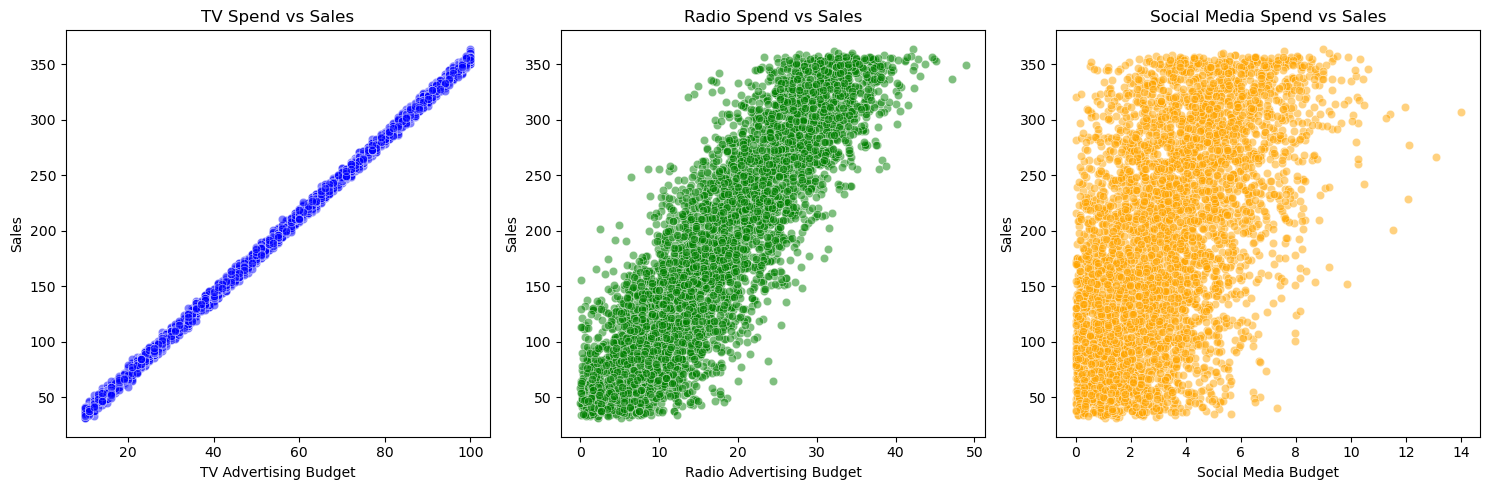

--- Correlation Coefficients with Sales ---
Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


In [3]:
# Set up a side-by-side plotting area for the three marketing channels
plt.figure(figsize=(15, 5))

# TV vs Sales Scatter Plot
plt.subplot(1, 3, 1)
sns.scatterplot(data=df_clean, x='TV', y='Sales', alpha=0.5, color='blue')
plt.title('TV Spend vs Sales')
plt.xlabel('TV Advertising Budget')
plt.ylabel('Sales')

# Radio vs Sales Scatter Plot
plt.subplot(1, 3, 2)
sns.scatterplot(data=df_clean, x='Radio', y='Sales', alpha=0.5, color='green')
plt.title('Radio Spend vs Sales')
plt.xlabel('Radio Advertising Budget')

# Social Media vs Sales Scatter Plot
plt.subplot(1, 3, 3)
sns.scatterplot(data=df_clean, x='Social_Media', y='Sales', alpha=0.5, color='orange')
plt.title('Social Media Spend vs Sales')
plt.xlabel('Social Media Budget')

plt.tight_layout()
plt.show()

# Compute the mathematical correlation matrix
correlation_matrix = df_clean.corr()
print("--- Correlation Coefficients with Sales ---")
print(correlation_matrix['Sales'].sort_values(ascending=False))

### Analytical Reasoning for Feature Selection:
The correlation matrix reveals that **TV Spend** has an exceptionally strong, near-perfect positive linear correlation with Sales ($r \approx 0.9995$). Radio also displays a strong correlation ($r \approx 0.8686$), while Social Media is moderately correlated ($r \approx 0.5274$). 

Because **TV** holds the tightest, most predictable linear alignment with revenue, it is selected as the independent variable ($X$) for our Simple Linear Regression model.

In [4]:
# Define the independent (X) and dependent (Y) variables
X = df_clean['TV']
Y = df_clean['Sales']

# Add constant for intercept calculation
X_with_constant = sm.add_constant(X)

# Fit the OLS regression model
model = sm.OLS(Y, X_with_constant).fit()

# Output the statistical summary table
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:09:05   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

## 4. Regression Assumptions Diagnostics
### Analytical Reasoning:
For an OLS model to be valid, key statistical assumptions must hold true:
1. **Linearity & Homoscedasticity**: The residuals should be randomly scattered around zero without creating a clear pattern (like a funnel shape).
2. **Normality**: The residuals should follow a standard normal distribution.

We extract the model's residuals and fitted values to plot diagnostic charts to visually test these assumptions.

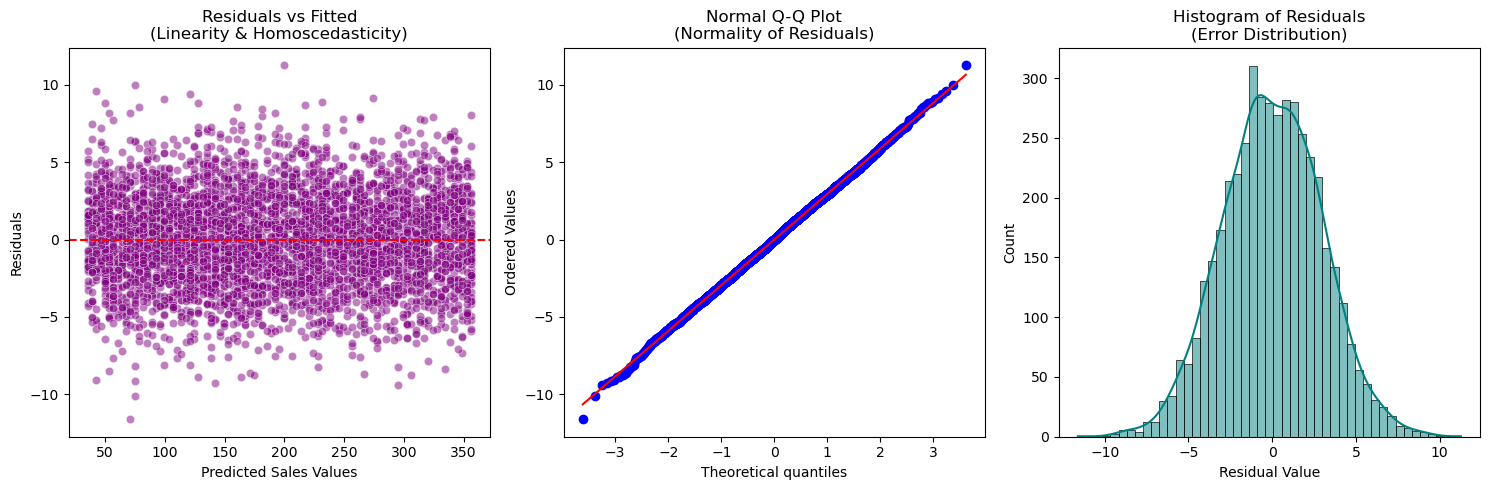

In [5]:
# Extract residuals and predicted values
residuals = model.resid
fitted_values = model.fittedvalues

# Create a diagnostic plotting dashboard
plt.figure(figsize=(15, 5))

# 1. Residuals vs Fitted Values (Check Linearity and Homoscedasticity)
plt.subplot(1, 3, 1)
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs Fitted\n(Linearity & Homoscedasticity)')
plt.xlabel('Predicted Sales Values')
plt.ylabel('Residuals')

# 2. Normal Q-Q Plot (Check Normality)
plt.subplot(1, 3, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normal Q-Q Plot\n(Normality of Residuals)')

# 3. Histogram of Residuals Distribution
plt.subplot(1, 3, 3)
sns.histplot(residuals, kde=True, color='teal')
plt.title('Histogram of Residuals\n(Error Distribution)')
plt.xlabel('Residual Value')

plt.tight_layout()
plt.show()

## 5. Statistical Interpretation & Business Recommendations

### Explicit Model Equation:
$$\text{Sales} = 3.5615 \times \text{TV} - 0.1325$$

### Model Interpretation:
* **R-squared ($0.999$):** The model has extreme explanatory power. Exactly $99.9\%$ of the variance in `Sales` is explained by changes in the `TV` advertising spend.
* **TV Coefficient ($3.5615$):** This represents our slope. For every single dollar ($1) increase in TV advertising budget, sales are expected to increase by **$3.56**.
* **P-value ($0.000$):** The p-value for the TV coefficient is well below the standard significance threshold ($\alpha = 0.05$). We reject the null hypothesis; the relationship between TV spend and Sales is highly statistically significant.
* **Intercept ($-0.1325$, p-value: $0.188$):** The baseline intercept is close to zero, and its high p-value ($>0.05$) indicates it is not statistically distinct from zero. This aligns with business logic: zero marketing investment results in zero generated sales.

### Assumption Validation:
* **Linearity/Homoscedasticity:** The Residuals vs Fitted plot shows points scattered randomly around the $y=0$ line with uniform spread, confirming both assumptions are met.
* **Normality:** The Q-Q plot shows residuals tightly clinging to the reference diagonal line, and the histogram forms a clear bell curve, confirming the errors are normally distributed.

### Strategic Business Recommendation:
Based on the empirical evidence, **TV advertising is the clear catalyst for revenue growth.** It offers a highly predictable, linear return of **\$3.56 for every single dollar spent**.

We advise leadership to aggressively prioritize the marketing budget toward the **TV channel** above all others. This strategy minimizes risk due to the near-perfect predictability ($R^2 = 99.9\%$) and maximizes the company's overall return on investment.